# Solar Flare Spectroscopy Project DRAFT

In [233]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy import units as u, constants as c
from scipy import signal
from scipy.optimize import curve_fit
import sunpy

## Load Data and Flare Timing

Load NPZ data, query GOES flare timing

In [2]:
# Load NPZ data
data_path = "/Users/lyniya/Downloads/socal_spectra_20240808_common_wavegrid.npz"
data = np.load(data_path)

print("Keys:", list(data.keys()))
print("Number of exposures:", len(data['bjd']))
duration = (data['bjd'].max() - data['bjd'].min()) * 24
print("Duration:", duration, "hours")

Keys: ['wave', 'flux', 'bjd', 'texp', 'filename']
Number of exposures: 150
Duration: 2.5249523408710957 hours


In [3]:
from sunpy.net import Fido
from sunpy.net import attrs as a

event_type = "FL"
tstart = "2024-08-08"
tend = "2024-08-09"  

# Search for X-class flares on Aug 8, 2024
result = Fido.search(a.Time(tstart, tend),
                     a.hek.EventType(event_type),
                     a.hek.FL.GOESCls > "X1.0",
                     a.hek.OBS.Observatory == "GOES")

hek_results = result["hek"]

# Filter columns to see the timing
filtered_results = hek_results["event_starttime", "event_peaktime", 
                               "event_endtime", "fl_goescls"]
print(filtered_results)

    event_starttime          event_peaktime          event_endtime      fl_goescls
----------------------- ----------------------- ----------------------- ----------
2024-08-08 19:01:00.000 2024-08-08 19:35:00.000 2024-08-08 19:57:00.000       X1.3


In [234]:
# Check if KPF observations captured the flare
from astropy.time import Time

time_obj = Time(data['bjd'], format='jd')

print("My observations:", time_obj[0].iso, "to", time_obj[-1].iso)


My observations: 2024-08-08 18:50:52.553 to 2024-08-08 21:22:22.381


# Visualize Flare

Plot GOES X-ray flux and KPF observation times to see the flare timeline.
GOES light curve showing flare start, peak, and end

In [235]:
# Define flare timing
flare_start = Time("2024-08-08 19:01:00.000").jd
flare_peak = Time("2024-08-08 19:35:00.000").jd
flare_end = Time("2024-08-08 19:57:00.000").jd

# Convert to datetime for plotting
flare_start_dt = Time(flare_start, format='jd').datetime
flare_peak_dt = Time(flare_peak, format='jd').datetime
flare_end_dt = Time(flare_end, format='jd').datetime

In [237]:
def detect_observation_gaps(data, max_gap_minutes=2):
    # Loop through each time point
    for i in range(1, len(data['bjd'])):
        # Calculate time difference in minutes
        time_diff_minutes = (data['bjd'][i] - data['bjd'][i-1]) * 24 * 60
        
        # If there's a gap, print it
        if time_diff_minutes > max_gap_minutes:
            start_time = Time(data['bjd'][i-1], format='jd').iso[11:19]
            end_time = Time(data['bjd'][i], format='jd').iso[11:19]
            print(f"Gap: {start_time} to {end_time} ({time_diff_minutes:.1f} min)")

detect_observation_gaps(data)

Gap: 19:06:00 to 19:08:01 (2.0 min)


In [239]:
# Find observation closest to flare peak
flare_peak_bjd = 2460531.315972222  # Your X1.3 flare peak time

# Calculate time differences
time_differences = [abs(bjd - flare_peak_bjd) for bjd in data['bjd']]

# Find the minimum difference
closest_idx = time_differences.index(min(time_differences))

# Get the closest observation info
closest_obs_time = Time(data['bjd'][closest_idx], format='jd')
flare_peak_time = Time(flare_peak_bjd, format='jd')
time_diff_minutes = min(time_differences) * 24 * 60

print(f"Flare peak time: {flare_peak_time.iso}")
print(f"Closest observation: #{closest_idx + 1} at {closest_obs_time.iso}")
print(f"Time difference: {time_diff_minutes:.1f} minutes")

Flare peak time: 2024-08-08 19:35:00.000
Closest observation: #44 at 2024-08-08 19:35:17.103
Time difference: 0.3 minutes


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

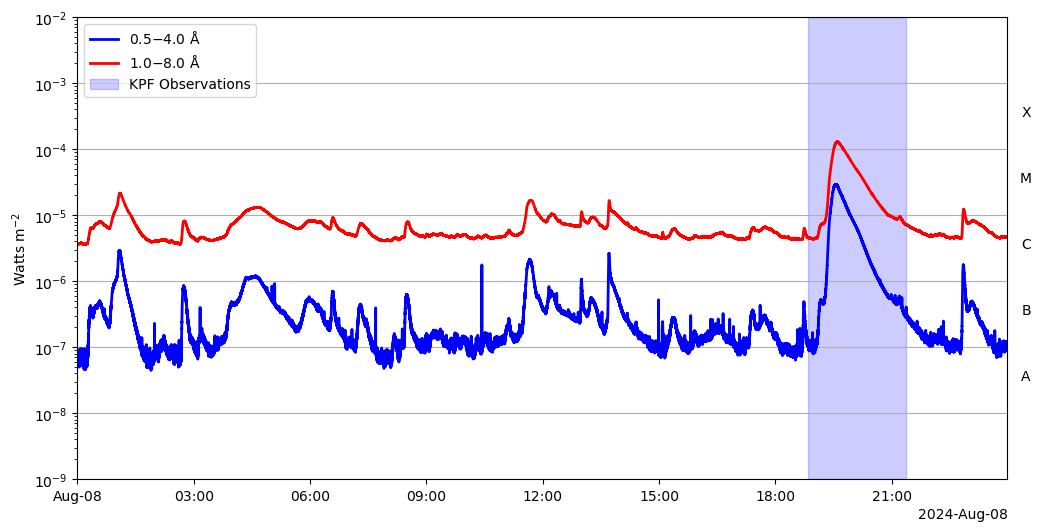

In [241]:

from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries
import pandas as pd
from astropy.time import Time

# Get GOES data
tr = a.Time('2024-08-08 00:00', '2024-08-08 23:59')
results = Fido.search(tr, a.Instrument.xrs & a.goes.SatelliteNumber(16))
files = Fido.fetch(results)
goes = TimeSeries(files[0])

# Convert your KPF observation times to datetime
kpf_start = Time(data['bjd'].min(), format='jd').datetime
kpf_end = Time(data['bjd'].max(), format='jd').datetime

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
goes.plot(axes=ax)
ax.axvspan(
    kpf_start,
    kpf_end,
    alpha=0.2, color='blue', label='KPF Observations'
)

# Add flare timing
flare_start_dt = Time(flare_start, format='jd').datetime
flare_peak_dt = Time(flare_peak, format='jd').datetime
flare_end_dt = Time(flare_end, format='jd').datetime

ax.legend(loc=2)
ax.set_yscale('log')
ax.set_xlim(tr.start.to_datetime(), tr.end.to_datetime())
plt.show()

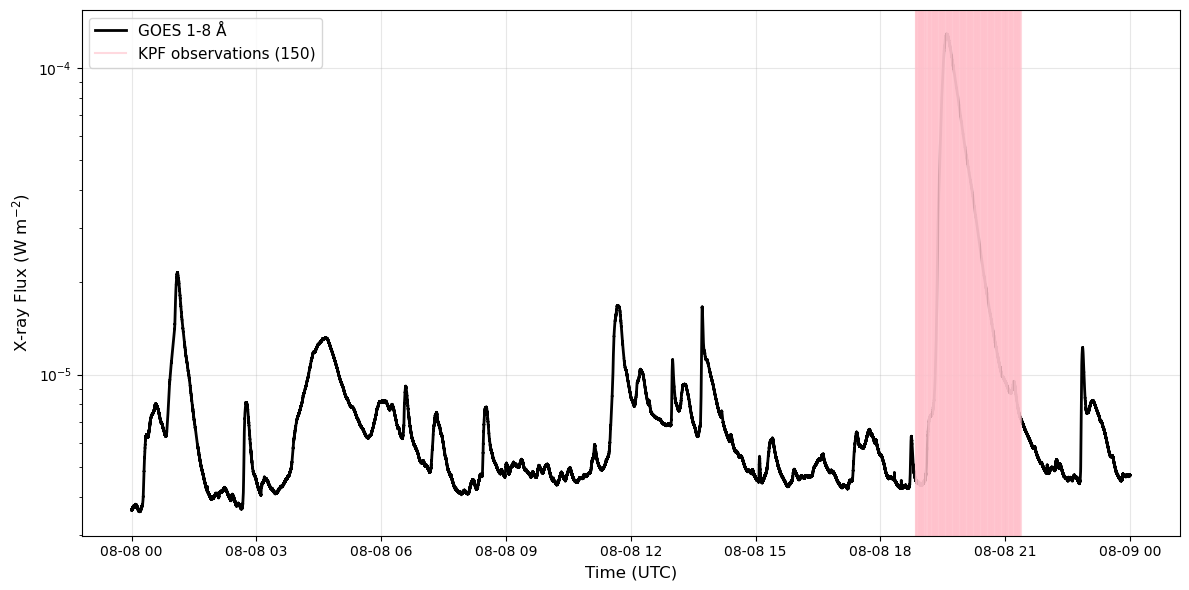

In [242]:
from sunpy.time import parse_time

fig, ax = plt.subplots(figsize=(12, 6))
goes_df = goes.to_dataframe()
red_channel = goes_df['xrsb']
times = goes_df.index

ax.plot(times, red_channel, 'black', linewidth=2, label='GOES 1-8 Å')
kpf_obs_times = [Time(bjd, format='jd').datetime for bjd in data['bjd']]

for i, obs_time in enumerate(kpf_obs_times):
    if i == 0:  # Only label the first one for the legend
        ax.axvline(obs_time, color='pink', alpha=0.6, linewidth=1.5, label=f'KPF observations ({len(kpf_obs_times)})')
    else:
        ax.axvline(obs_time, color='pink', alpha=0.6, linewidth=1.5)

ax.set_yscale('log')
ax.set_ylabel('X-ray Flux (W m$^{-2}$)', fontsize=12)
ax.set_xlabel('Time (UTC)', fontsize=12) 
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Create Reference Spectrum


In [11]:
import ipywidgets as widgets
def plot_goes_with_observation_range(start_obs, end_obs):
    start_idx = start_obs - 1
    end_idx = end_obs - 1
    
    start_time = Time(data['bjd'][start_idx], format='jd').datetime
    end_time = Time(data['bjd'][end_idx], format='jd').datetime
    
    fig, ax = plt.subplots(figsize=(12, 6))
    goes_df = goes.to_dataframe()
    ax.plot(goes_df.index, goes_df['xrsb'], 'black', linewidth=2, label='GOES 1-8 Å')
    
    # Shade the KPF observation period
    kpf_start = Time(data['bjd'].min(), format='jd').datetime
    kpf_end = Time(data['bjd'].max(), format='jd').datetime
    ax.axvspan(kpf_start, kpf_end, alpha=0.3, color='pink', label='KPF observations')
    
    # Flare peak line
    flare_peak_dt = Time(2460531.315972222, format='jd').datetime
    ax.axvline(flare_peak_dt, color='orange', linestyle='-', linewidth=2, label='Flare peak')
    
    # Start and end lines
    ax.axvline(start_time, color='red', linestyle='--', linewidth=2, label=f'Start: obs #{start_obs}')
    ax.axvline(end_time, color='blue', linestyle='--', linewidth=2, label=f'End: obs #{end_obs}')
    
    ax.set_xlim(parse_time('2024-08-08T18:30:00').datetime, 
                parse_time('2024-08-08T21:45:00').datetime)
    
    ax.set_yscale('log')
    ax.set_ylabel('X-ray Flux (W m$^{-2}$)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Selected range: obs {start_obs} to {end_obs} ({end_obs - start_obs + 1} observations)")

# Sliders
start_slider = widgets.IntSlider(value=1, min=1, max=len(data['bjd']), description='Start:')
end_slider = widgets.IntSlider(value=15, min=1, max=len(data['bjd']), description='End:')
widgets.interact(plot_goes_with_observation_range, start_obs=start_slider, end_obs=end_slider)

interactive(children=(IntSlider(value=1, description='Start:', max=150, min=1), IntSlider(value=15, descriptio…

<function __main__.plot_goes_with_observation_range(start_obs, end_obs)>

In [12]:
# Create reference spectrum from selected observations
start_obs = 1
end_obs = 15

# Convert to array indices 
start_idx = start_obs - 1
end_idx = end_obs - 1

# Select the range of spectra
selected_spectra = data['flux'][start_idx:end_idx+1]
refflux = np.mean(selected_spectra, axis=0)

start_time = Time(data['bjd'][start_idx], format='jd').iso[11:19]
end_time = Time(data['bjd'][end_idx], format='jd').iso[11:19]

print(f"Reference created from observations {start_obs} to {end_obs}")
print(f"Time range: {start_time} to {end_time} UTC")
print(f"Total spectra averaged: {len(selected_spectra)}")

Reference created from observations 1 to 15
Time range: 18:50:52 to 19:04:58 UTC
Total spectra averaged: 15


## Step 4: Change in Flux from Reference

Compare flare spectra to reference to see what changed.

- Subtraction: flare - reference
- Division: flare / reference

In [15]:
def test_reference_analysis(ref_start, ref_end, test_start, test_end, subtract_mode):
    # Create reference from first range
    ref_start_idx = ref_start - 1
    ref_end_idx = ref_end - 1
    ref_spectra = data['flux'][ref_start_idx:ref_end_idx+1]
    test_refflux = np.mean(ref_spectra, axis=0)
    
    # Create test 'flare' spectrum
    test_start_idx = test_start - 1
    test_end_idx = test_end - 1
    test_spectra = data['flux'][test_start_idx:test_end_idx+1]
    test_flux = np.mean(test_spectra, axis=0)
    
    # Compare them
    if subtract_mode:
        diff_flux = test_flux - test_refflux
        method = "Subtraction"
        ylabel = "Flux difference"
    else:
        diff_flux = test_flux / test_refflux
        method = "Division (ratio)"
        ylabel = "Flux ratio"
    
    # Plot
    o = 43  # h-alpha order
    plt.figure(figsize=(12, 6))
    plt.plot(data['wave'][o], diff_flux[o])
    if not subtract_mode:
        plt.axhline(1.0, color='gray', ls=':', alpha=0.7, label='No change')
    else:
        plt.axhline(0.0, color='gray', ls=':', alpha=0.7, label='No change')
    plt.axvline(6564.62, color='k', ls='--', label='H-alpha')
    plt.xlim(6555, 6575)
    plt.title(f'{method}: Reference (obs {ref_start}-{ref_end}) vs Test (obs {test_start}-{test_end})')
    plt.ylabel(ylabel)
    plt.xlabel('Wavelength (Å)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    ref_time1 = Time(data['bjd'][ref_start_idx], format='jd').iso[11:19]
    ref_time2 = Time(data['bjd'][ref_end_idx], format='jd').iso[11:19]
    test_time1 = Time(data['bjd'][test_start_idx], format='jd').iso[11:19]
    test_time2 = Time(data['bjd'][test_end_idx], format='jd').iso[11:19]
    
    print(f"Reference: obs {ref_start}-{ref_end} ({ref_time1} to {ref_time2})")
    print(f"Test: obs {test_start}-{test_end} ({test_time1} to {test_time2})")

subtract_toggle = widgets.Checkbox(value=False, description='Subtract mode')
ref_start_slider = widgets.IntSlider(value=1, min=1, max=len(data['bjd']), description='Ref start:')
ref_end_slider = widgets.IntSlider(value=15, min=1, max=len(data['bjd']), description='Ref end:')
test_start_slider = widgets.IntSlider(value=16, min=1, max=len(data['bjd']), description='Test start:')
test_end_slider = widgets.IntSlider(value=20, min=1, max=len(data['bjd']), description='Test end:')

widgets.interact(test_reference_analysis, 
                ref_start=ref_start_slider, ref_end=ref_end_slider,
                test_start=test_start_slider, test_end=test_end_slider,
                subtract_mode=subtract_toggle)

interactive(children=(IntSlider(value=1, description='Ref start:', max=150, min=1), IntSlider(value=15, descri…

<function __main__.test_reference_analysis(ref_start, ref_end, test_start, test_end, subtract_mode)>

## Telluric Lines

In [135]:
telwave = fits.open('/Users/lyniya/Downloads/TAPAS_WMKO_NORAYLEIGH_SPEC_WVL.fits')[0].data
telflux = fits.open('/Users/lyniya/Downloads/TAPAS_WMKO_NORAYLEIGH_SPEC.fits')[0].data

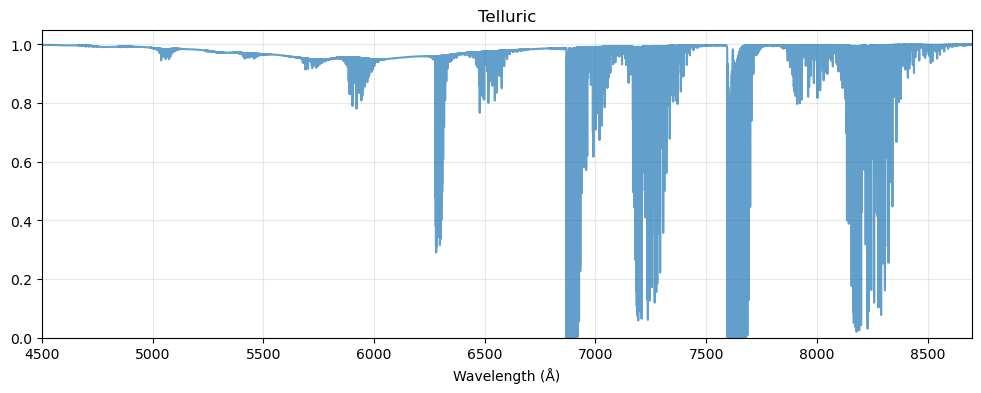

In [136]:
# Convert to Angstroms
telwave = telwave * 10

# Plot
plt.figure(figsize=(12, 4))
plt.plot(telwave, telflux, color='C0', alpha=0.7)
plt.xlabel('Wavelength (Å)')
plt.title('Telluric')
plt.xlim(4500, 8700)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

## h-alpha Analysis!! 


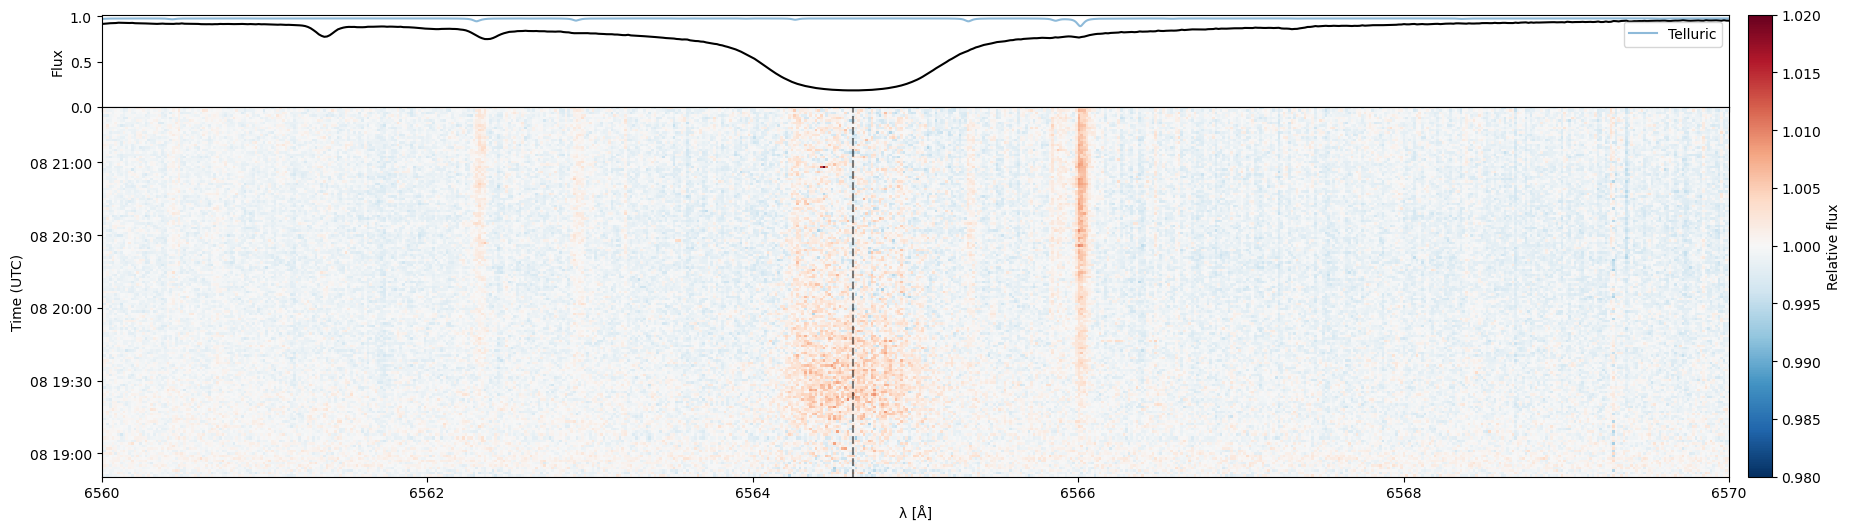

In [139]:
# Big residual plot with tellurics
o = 43
orderwave = data['wave'][o]

fig, (sax, ax) = plt.subplots(2, 1, figsize=(25, 6), sharex=True,
                              gridspec_kw={'height_ratios': [1, 4], 'hspace': 0})

# Top panel
sax.plot(orderwave, refflux[o], color='k')
tc = (telwave >= orderwave.min()) & (telwave <= orderwave.max())
sax.plot(telwave[tc], telflux[tc], color='C0', alpha=0.5, ls='-', label='Telluric')
sax.legend(loc='upper right')
sax.set(ylim=[0, 1.02], ylabel='Flux')

# Bottom panel
c = ax.pcolormesh(orderwave, dts, diff_flux[:, o], cmap='RdBu_r', vmin=0.98, vmax=1.02)
ax.set_ylabel('Time (UTC)')
ax.set_xlabel('λ [Å]')

# Colorbar
fig.colorbar(c, ax=[sax, ax], label='Relative flux', pad=0.01)

ax.set_xlim(6495, 6575)
sax.set_xlim(6495, 6575)

# Mark H-alpha line
ax.axvline(6564.62, color='k', ls='--', alpha=0.5)

ax.set_xlim(6564.62, 6570)

plt.show()


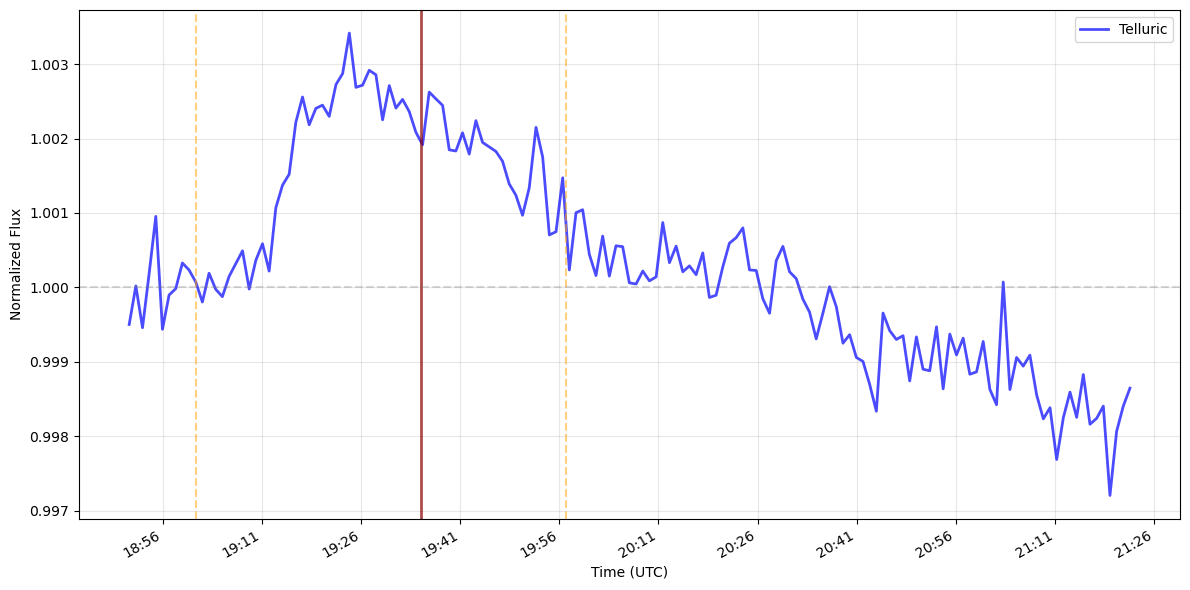

In [144]:
halpha_order = 44
telluric_order = 48

halpha_wave = wave[halpha_order, :]
halpha_flux = flux[:, halpha_order, :]

tel_wave = wave[telluric_order, :]
tel_flux = flux[:, telluric_order, :]

halpha_center = 6564.62
halpha_width = .5
halpha_mask = (halpha_wave > halpha_center - halpha_width) & (halpha_wave < halpha_center + halpha_width)

tel_mask = (tel_wave > 6920) & (tel_wave < 6930)

halpha_sum = []
telluric_sum = []

for i in range(len(flux)):
    halpha_sum.append(np.sum(halpha_flux[i, halpha_mask]))
    telluric_sum.append(np.sum(tel_flux[i, tel_mask]))

halpha_sum = np.array(halpha_sum)
telluric_sum = np.array(telluric_sum)

# Normalize
halpha_norm = halpha_sum / np.mean(halpha_sum[:10])
telluric_norm = telluric_sum / np.mean(telluric_sum[:10])

from astropy.time import Time
import matplotlib.dates as mdates

times = Time(bjd, format='jd', scale='tdb').to_datetime()

# Flare times
start = Time('2024-08-08 19:01:00', format='iso', scale='utc').datetime
peak = Time('2024-08-08 19:35:00', format='iso', scale='utc').datetime
end = Time('2024-08-08 19:57:00', format='iso', scale='utc').datetime

# Plot
plt.figure(figsize=(12, 6))
#plt.plot(times, telluric_norm, 'b-', linewidth=2, label='Telluric', alpha=0.7)
#plt.plot(times, halpha_norm, 'r-', linewidth=2, label='H-alpha', alpha=0.7)

plt.plot(times, halpha_norm/telluric_norm, 'b-', linewidth=2, label='Telluric', alpha=0.7)

plt.axvline(start, color='orange', linestyle='--', alpha=0.5)
plt.axvline(peak, color='darkred', linestyle='-', linewidth=2, alpha=0.7)
plt.axvline(end, color='orange', linestyle='--', alpha=0.5)
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
plt.gcf().autofmt_xdate()

plt.xlabel('Time (UTC)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom-ins on wavelength ranges of interest

In [209]:
# Original function definitions
def plot_region_around(wave0, dwave, order, figsize=(4,6),
                       savefig=False, showtellurics=True):
    
    orderwave = wave[order,:]
    orderflux = flux[:,order,:]
    
    # Wavelength region
    sel = (orderwave>wave0-dwave) & (orderwave<wave0+dwave)
    relwave = (orderwave[sel]-wave0)
    
    # Flux
    linedata = np.array([f[sel] for f in orderflux])
    avgflux  = np.mean(orderflux[ref], axis=0)[sel]
    diff_flux = linedata/avgflux
            
    # Plotting
    fig, (sax, ax) = plt.subplots(2,1,figsize=figsize, sharex=True,
                             gridspec_kw={'height_ratios':[1,4],
                                          'hspace':0})
    # Top axis for spectrum
    sax.plot(relwave, avgflux, color='k')
    sax.set(ylim=[0,1.02], ylabel='Flux')
    if showtellurics:
        tc = np.abs(telwave-wave0) < dwave
        sax.plot(telwave[tc]-wave0, telflux[tc], color='C0', alpha=0.5, ls='-', zorder=10)
        
    # Axis formatting
    dateformat(ax, which='y')
    ax.set(xlim=[-dwave, dwave], ylabel='UTC', 
           xlabel=r'$\lambda$ [$\AA$] - {} $\AA$'.format(wave0))
    
    # Colormap
    cmap = 'RdBu_r'
    c = ax.pcolormesh(relwave, dts, diff_flux, cmap=cmap, vmin=0.99, vmax=1.01)
    
    left, bottom, top = (ax.get_position().xmax, 
                         ax.get_position().ymin, 
                         ax.get_position().ymax)
    width = 0.05
    height = top-bottom
    cbar_ax = fig.add_axes([left+width/2, bottom, width*6/figsize[0], height])
    cbar = plt.colorbar(c, cax=cbar_ax, label='Relative flux')
    
    if savefig:
        plt.savefig(f'flares/{date}_{wave0}.png', bbox_inches='tight')
        
    return fig, (ax, sax, cbar_ax)

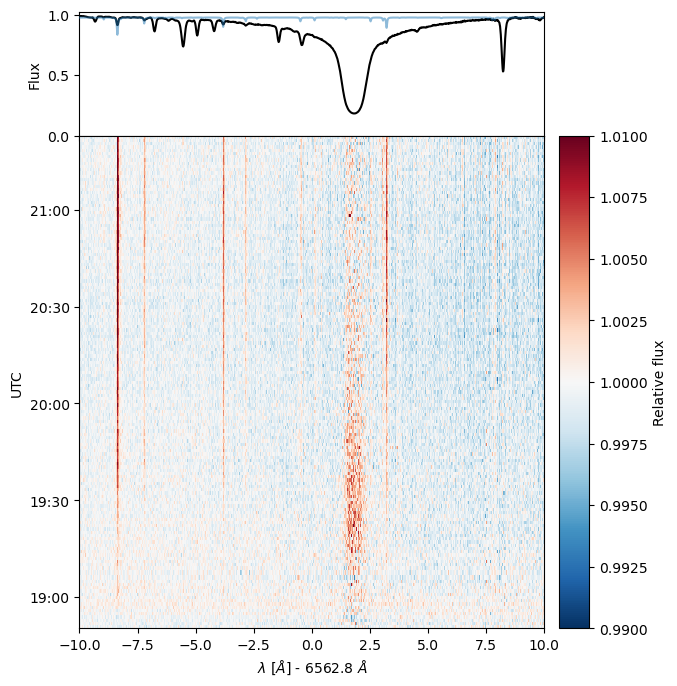

In [231]:
# H-alpha

fig, axes = plot_region_around(6562.8, 10, order=43, showtellurics=True, figsize=(6,8))
plt.show()

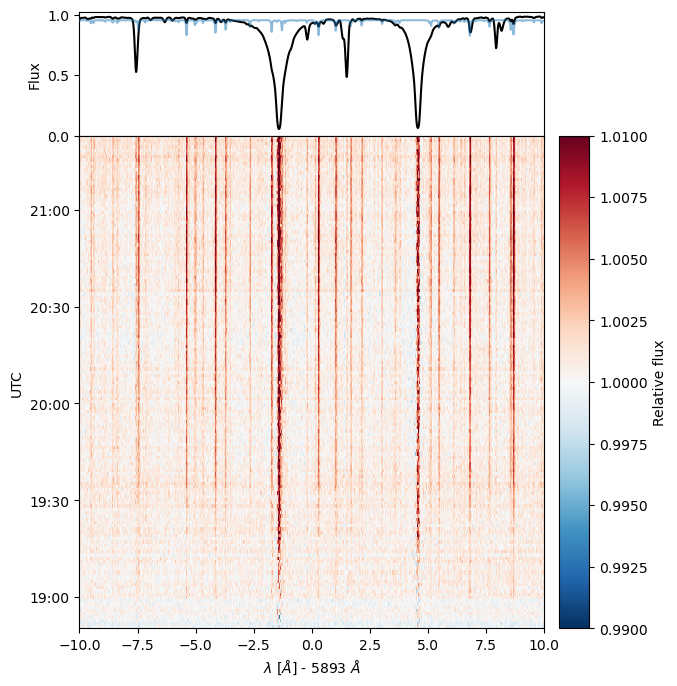

In [230]:
# Na D

fig, axes = plot_region_around(5893, 10, order=33, showtellurics=True, figsize=(6,8))
plt.show()

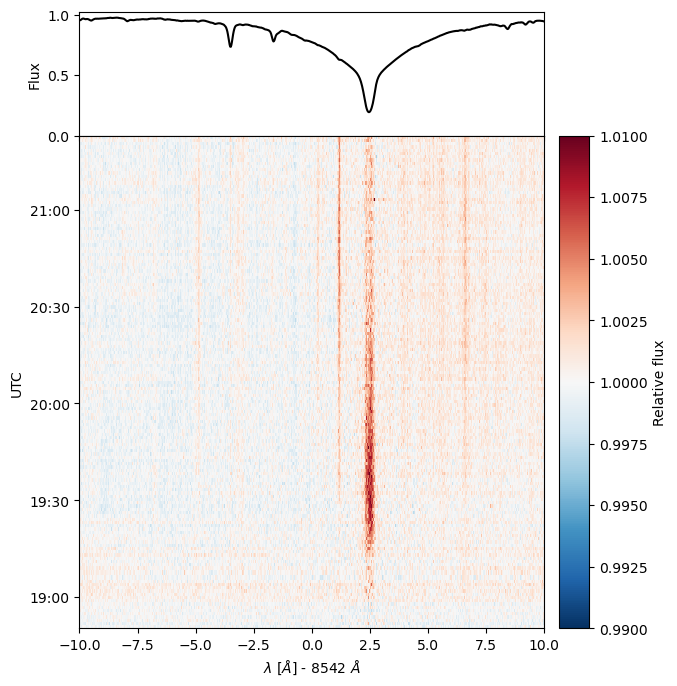

In [228]:
# Ca II 8542

fig, axes = plot_region_around(8542, 10, order=65, showtellurics=False, figsize=(6,8))
plt.show()

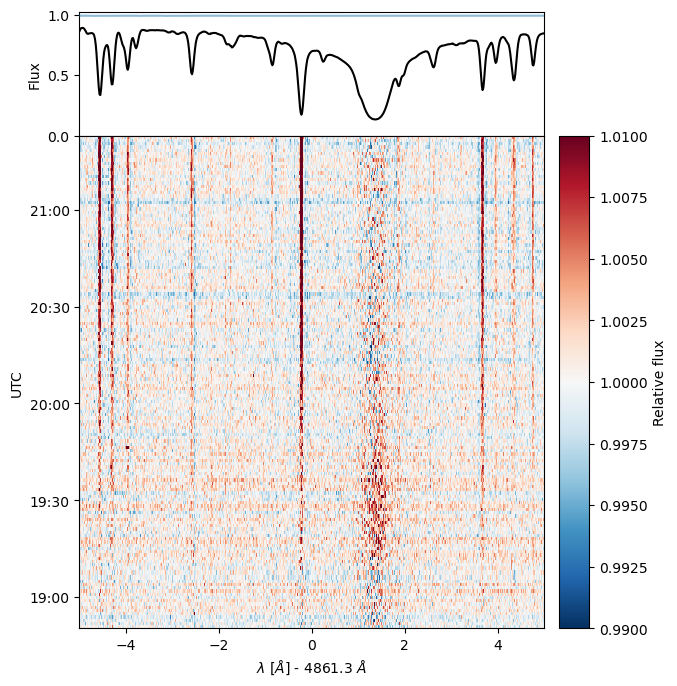

In [232]:
# H-beta

fig, axes = plot_region_around(4861.3, 5, order=11, showtellurics=True, figsize=(6,8))
plt.show()